# NASA RW Dataset Exploration

Uniform charge/discharge random-walk cells **RW9–RW12** (Option A: operational steps).

## Current profile types in this dataset

NASA labels each **step** with a `comment` string (and `type`: `C` / `D` / `R`).  
There are **15** unique comments across RW9–RW12, which map to **7 profile families** — not a large library of CCCV / multistep / pulsed families like a charge-optimization benchmark.

| Family | NASA `comment`(s) | Shape |
|--------|-------------------|--------|
| **RW piecewise CC** | `charge (random walk)`, `discharge (random walk)` | One of 12 constant setpoints for ≤5 min or until V leaves [3.2, 4.2] V |
| **RW micro-rest** | `rest (random walk)` | ~0 A, &lt;1 s between RW steps |
| **CC–CV reference charge** | `reference charge` | 2 A CC → 4.2 V CV until I &lt; 0.01 A |
| **CC reference discharge** | `reference discharge` | 2 A until V ≤ 3.2 V |
| **Low-current CC** | `low current discharge at 0.04A` | ~0.04 A OCV curve |
| **Pulsed 1 A (discharge)** | `pulsed load (discharge)` / `(rest)` | 10 min @ 1 A, 20 min rest (repeated) |
| **Pulsed 1 A (charge)** | `pulsed charge (charge)` / `(rest)` | 10 min @ −1 A, 20 min rest |
| **Plain rest** | `rest post …`, etc. | I ≈ 0 between characterization blocks |

Default training filter `step_mode: rw_operational` keeps only the **first two rows** (~99.7% of steps).

In [5]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from rw_transfer.config import load_config
from rw_transfer.data.series import load_battery_series
from rw_transfer.constants import CELL_ORDER

cfg = load_config(ROOT / "configs" / "default.yaml")
matlab_dir = cfg["data"]["matlab_dir"]
step_mode = cfg["data"]["step_mode"]
print("Matlab dir:", matlab_dir)
print("Step mode:", step_mode)

Matlab dir: /data/battery_RW_NASA/NASA_RW/dataset/Battery_Uniform_Distribution_Charge_Discharge_DataSet_2Post/Battery_Uniform_Distribution_Charge_Discharge_DataSet_2Post/data/Matlab
Step mode: all


In [6]:
rw9 = load_battery_series(matlab_dir, "RW9", step_mode=step_mode)

rw9_df = pd.DataFrame({
    "time_s":           rw9.time_s,
    "relative_time_s":  rw9.relative_time_s,
    "voltage_v":        rw9.voltage_v,
    "current_a":        rw9.current_a,
    "temperature_c":    rw9.temperature_c,
    "age":              rw9.age,
    "comment":          rw9.comment,
    "step_index":       rw9.step_index,
})

print(f"RW9 — {len(rw9_df):,} rows × {rw9_df.shape[1]} columns")
rw9_df.head(20)

RW9 — 8,532,073 rows × 8 columns


,time_s,relative_time_s,voltage_v,current_a,temperature_c,age,comment,step_index
0,5.04,0.04,3.838,-2.007,24.385300,0.0,reference charge,0
1,15.04,10.04,3.865,-2.000,24.385300,0.0,reference charge,0
2,25.04,20.04,3.878,-2.000,24.291630,0.0,reference charge,0
3,35.04,30.04,3.888,-2.000,24.244801,0.0,reference charge,0
4,45.04,40.04,3.895,-2.000,24.260410,0.0,reference charge,0
5,55.04,50.04,3.900,-2.000,24.229191,0.0,reference charge,0
6,65.04,60.04,3.905,-2.000,24.197960,0.0,reference charge,0
7,75.04,70.04,3.908,-2.000,24.166740,0.0,reference charge,0
8,85.04,80.04,3.911,-2.000,24.119900,0.0,reference charge,0
9,95.04,90.04,3.914,-2.000,24.166740,0.0,reference charge,0


In [7]:
out_csv = ROOT / "RW9_dataset.csv"
rw9_df.to_csv(out_csv, index=False)
print(f"Saved → {out_csv}  ({out_csv.stat().st_size / 1e6:.1f} MB)")

Saved → /data/battery_RW_NASA/RW9_dataset.csv  (681.8 MB)


In [4]:
rows = []
for cell in CELL_ORDER:
    s = load_battery_series(matlab_dir, cell, step_mode=step_mode)
    rows.append({
        "cell": cell,
        "samples": len(s.time_s),
        "duration_h": round(s.duration_hours, 2),
        "V_min": float(s.voltage_v.min()),
        "V_max": float(s.voltage_v.max()),
        "I_min": float(s.current_a.min()),
        "I_max": float(s.current_a.max()),
    })
pd.DataFrame(rows)

,cell,samples,duration_h,V_min,V_max,I_min,I_max
0,RW9,8532073,3531.49,2.793,4.663,-4.618,4.797
1,RW10,8596025,3534.42,2.780,4.657,-4.621,4.622
2,RW11,8664510,3533.80,2.784,4.648,-4.617,4.658
3,RW12,8638882,3535.98,2.588,4.814,-4.619,4.620


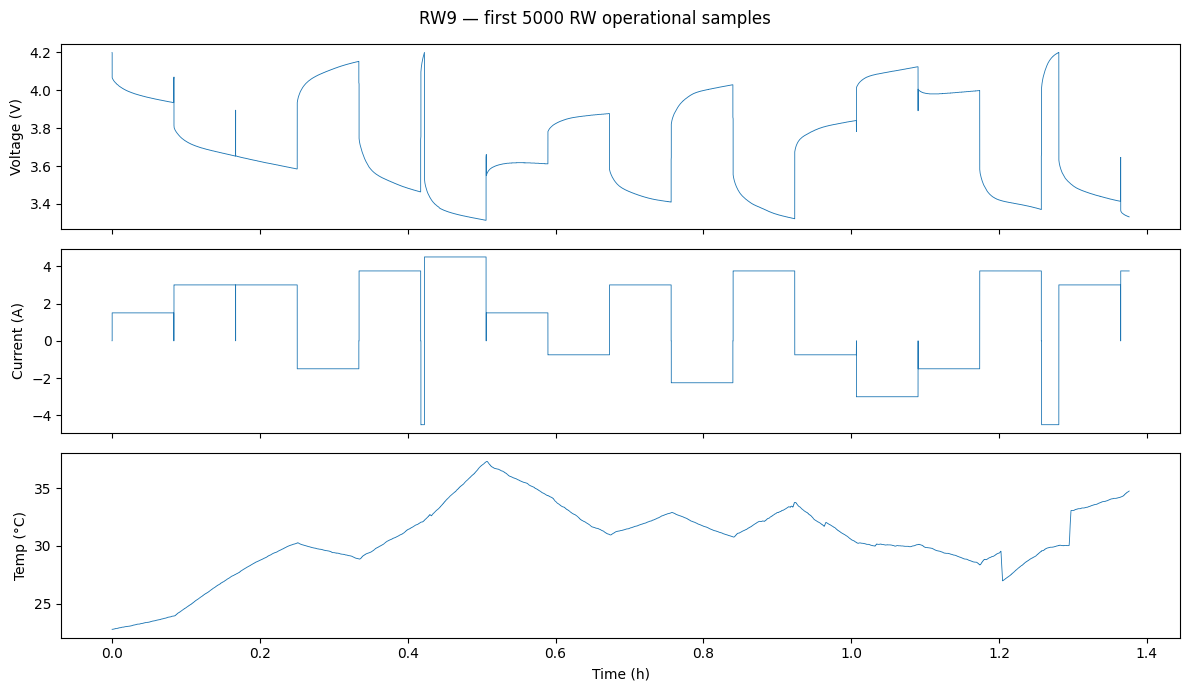

In [3]:
cell = "RW9"
s = load_battery_series(matlab_dir, cell, step_mode=step_mode)
n_plot = 5000
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
t_h = (s.time_s[:n_plot] - s.time_s[0]) / 3600
axes[0].plot(t_h, s.voltage_v[:n_plot], lw=0.6)
axes[0].set_ylabel("Voltage (V)")
axes[1].plot(t_h, s.current_a[:n_plot], lw=0.6)
axes[1].set_ylabel("Current (A)")
axes[2].plot(t_h, s.temperature_c[:n_plot], lw=0.6)
axes[2].set_ylabel("Temp (°C)")
axes[2].set_xlabel("Time (h)")
fig.suptitle(f"{cell} — first {n_plot} RW operational samples")
plt.tight_layout()
plt.show()

In [4]:
from collections import Counter

import numpy as np

from rw_transfer.data.mat_loader import load_cell_steps, mat_path_for_cell

# Inventory: all steps vs operational filter
rows = []
for cell in CELL_ORDER:
    path = mat_path_for_cell(matlab_dir, cell)
    all_steps = load_cell_steps(path, step_mode="all")
    op_steps = load_cell_steps(path, step_mode="rw_operational")
    for mode, steps in [("all", all_steps), ("rw_operational", op_steps)]:
        for s in steps:
            rows.append({
                "cell": cell,
                "step_mode": mode,
                "comment": s.comment,
                "type": s.step_type,
                "n_samples": len(s.current_a),
                "duration_s": float(s.time_s[-1] - s.time_s[0]) if len(s.time_s) > 1 else 0.0,
                "I_median": float(np.median(s.current_a)),
            })

inv = pd.DataFrame(rows)
summary = (
    inv.groupby(["step_mode", "comment", "type"], as_index=False)
    .agg(steps=("cell", "count"), samples=("n_samples", "sum"), duration_s_median=("duration_s", "median"))
    .sort_values(["step_mode", "steps"], ascending=[True, False])
)
summary

,step_mode,comment,type,steps,samples,duration_s_median
9,all,rest (random walk),R,220069,440137,0.550
1,all,discharge (random walk),D,110227,15076683,81.750
0,all,charge (random walk),C,109833,15588272,77.650
5,all,pulsed load (discharge),D,759,435470,599.960
6,all,pulsed load (rest),R,759,911153,1199.990
3,all,pulsed charge (charge),C,500,284773,599.960
4,all,pulsed charge (rest),R,500,600446,1199.990
7,all,reference charge,C,310,546891,17989.080
8,all,reference discharge,D,310,157235,4801.635
12,all,rest post reference charge,R,204,6324,299.990


In [5]:
# Map comments → profile family (per NASA README)
PROFILE_FAMILY = {
    "charge (random walk)": "RW CC (single random setpoint, charge)",
    "discharge (random walk)": "RW CC (single random setpoint, discharge)",
    "rest (random walk)": "RW micro-rest",
    "reference charge": "CC–CV (2 A → 4.2 V)",
    "reference discharge": "CC (2 A to 3.2 V)",
    "rest post reference charge": "Rest",
    "rest post reference discharge": "Rest",
    "low current discharge at 0.04A": "CC (~0.04 A, OCV)",
    "rest prior low current discharge": "Rest",
    "rest post low current discharge": "Rest",
    "pulsed load (discharge)": "Pulsed multistep — 1 A discharge leg",
    "pulsed load (rest)": "Pulsed multistep — rest leg",
    "pulsed charge (charge)": "Pulsed multistep — 1 A charge leg",
    "pulsed charge (rest)": "Pulsed multistep — rest leg",
    "rest post pulsed load or charge": "Rest",
}

all_inv = inv[inv["step_mode"] == "all"].copy()
all_inv["profile_family"] = all_inv["comment"].map(PROFILE_FAMILY)
fam = (
    all_inv.groupby("profile_family", as_index=False)
    .agg(steps=("comment", "count"), frac_steps=("comment", lambda x: len(x) / len(all_inv)))
    .sort_values("steps", ascending=False)
)
fam["frac_steps"] = (fam["frac_steps"] * 100).round(2)
fam.rename(columns={"frac_steps": "pct_of_all_steps"}, inplace=True)
print(f"Distinct profile families: {fam['profile_family'].nunique()}")
fam

Distinct profile families: 10


,profile_family,steps,pct_of_all_steps
8,RW micro-rest,220069,49.59
7,"RW CC (single random setpoint, discharge)",110227,24.84
6,"RW CC (single random setpoint, charge)",109833,24.75
5,Pulsed multistep — rest leg,1259,0.28
4,Pulsed multistep — 1 A discharge leg,759,0.17
9,Rest,523,0.12
3,Pulsed multistep — 1 A charge leg,500,0.11
0,CC (2 A to 3.2 V),310,0.07
2,CC–CV (2 A → 4.2 V),310,0.07
1,"CC (~0.04 A, OCV)",8,0.00


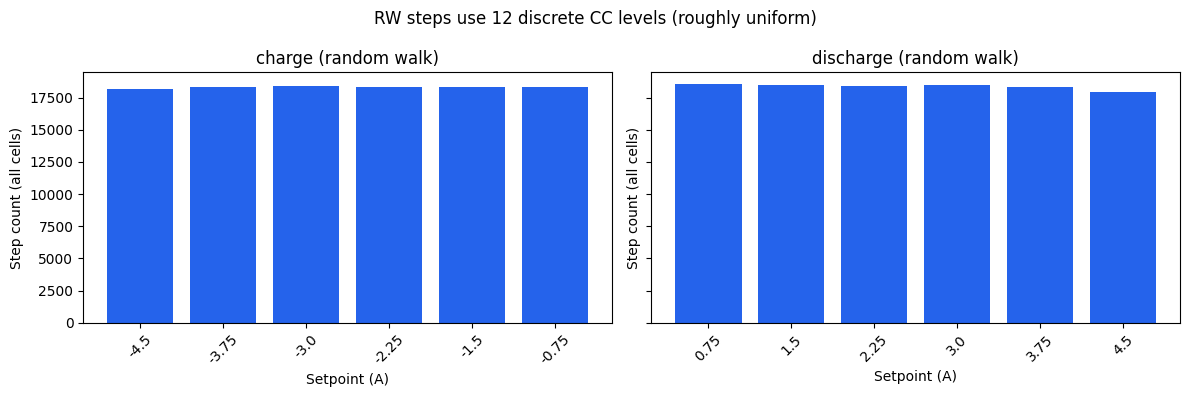

comment,charge (random walk),discharge (random walk)
setpoint_A,,
-4.50,18134,0
-3.75,18346,0
-3.00,18408,0
-2.25,18328,0
-1.50,18325,0
-0.75,18289,0
0.75,0,18534
1.50,0,18494
2.25,0,18437


In [6]:
# RW random-walk setpoints (12 levels; negative = charge in .mat convention)
RW_LEVELS = [-4.5, -3.75, -3.0, -2.25, -1.5, -0.75, 0.75, 1.5, 2.25, 3.0, 3.75, 4.5]

level_counts = Counter()
for cell in CELL_ORDER:
    for s in load_cell_steps(mat_path_for_cell(matlab_dir, cell), step_mode="all"):
        if s.comment not in ("charge (random walk)", "discharge (random walk)"):
            continue
        i = s.current_a
        active = i[np.abs(i) > 0.05]
        if active.size == 0:
            continue
        med = float(np.median(active))
        lvl = RW_LEVELS[int(np.argmin(np.abs(np.array(RW_LEVELS) - med)))]
        level_counts[(s.comment, lvl)] += 1

lc = pd.DataFrame(
    [(cmt, lvl, n) for (cmt, lvl), n in level_counts.items()],
    columns=["comment", "setpoint_A", "steps"],
).sort_values(["comment", "setpoint_A"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, cmt in zip(axes, ["charge (random walk)", "discharge (random walk)"]):
    sub = lc[lc["comment"] == cmt]
    ax.bar(sub["setpoint_A"].astype(str), sub["steps"], color="#2563EB")
    ax.set_title(cmt)
    ax.set_xlabel("Setpoint (A)")
    ax.set_ylabel("Step count (all cells)")
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("RW steps use 12 discrete CC levels (roughly uniform)")
plt.tight_layout()
plt.show()
lc.pivot(index="setpoint_A", columns="comment", values="steps").fillna(0).astype(int)

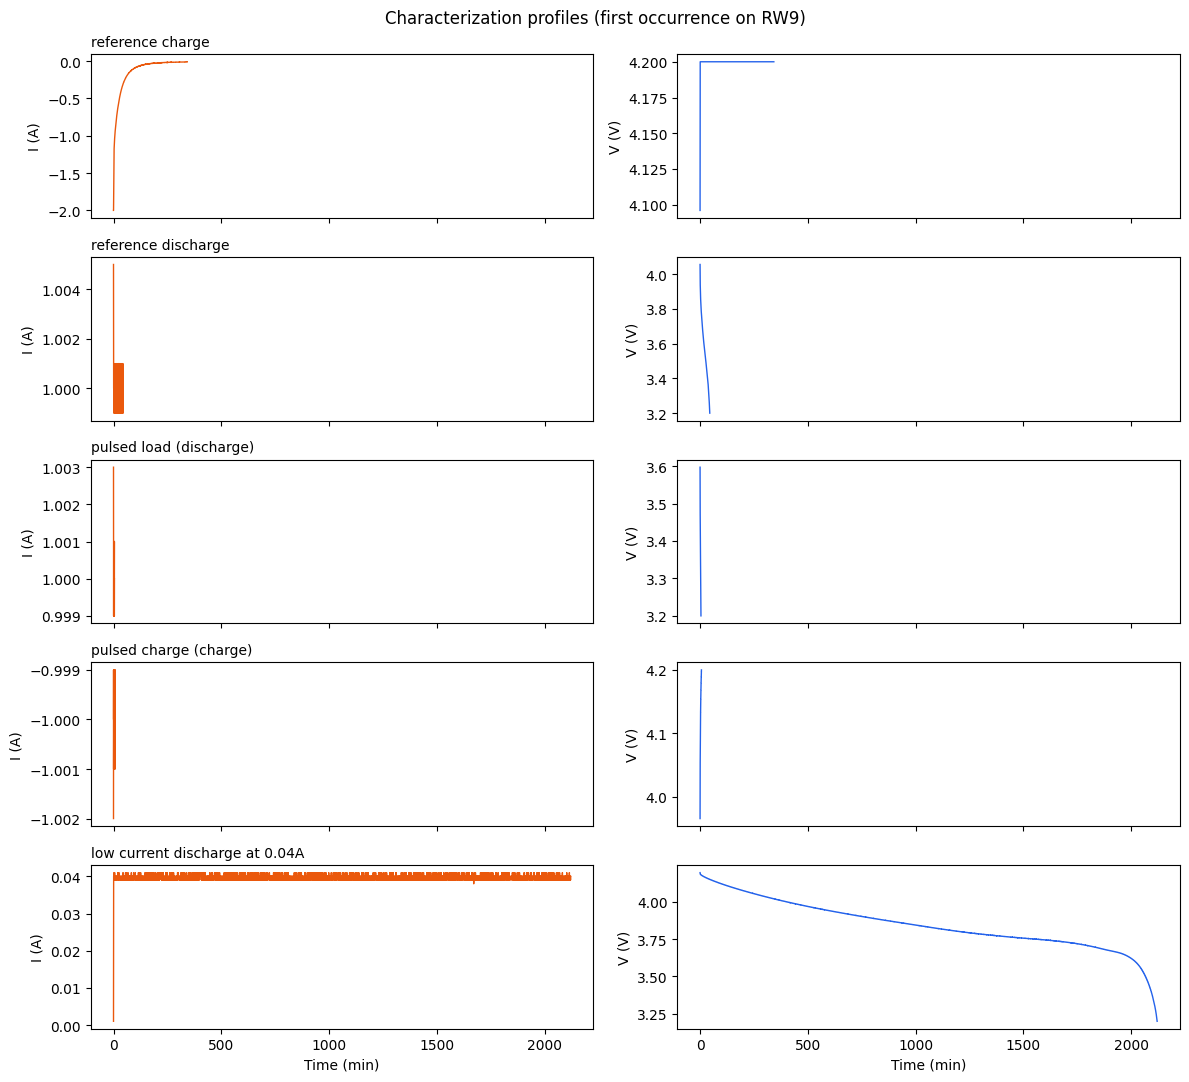

In [7]:
# One example step per non-RW family (RW9)
EXAMPLES = [
    "reference charge",
    "reference discharge",
    "pulsed load (discharge)",
    "pulsed charge (charge)",
    "low current discharge at 0.04A",
]

steps_rw9 = load_cell_steps(mat_path_for_cell(matlab_dir, "RW9"), step_mode="all")
by_comment = {s.comment: s for s in steps_rw9}

fig, axes = plt.subplots(len(EXAMPLES), 2, figsize=(12, 2.2 * len(EXAMPLES)), sharex="col")
for row, cmt in enumerate(EXAMPLES):
    s = by_comment[cmt]
    t_min = (s.time_s - s.time_s[0]) / 60.0
    axes[row, 0].plot(t_min, s.current_a, color="#EA580C", lw=1)
    axes[row, 0].set_ylabel("I (A)")
    axes[row, 1].plot(t_min, s.voltage_v, color="#2563EB", lw=1)
    axes[row, 1].set_ylabel("V (V)")
    axes[row, 0].set_title(cmt, fontsize=10, loc="left")
axes[-1, 0].set_xlabel("Time (min)")
axes[-1, 1].set_xlabel("Time (min)")
fig.suptitle("Characterization profiles (first occurrence on RW9)")
plt.tight_layout()
plt.show()